In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
ticket=pd.read_csv('Support_tickets.csv')
print(ticket.head())
print(ticket.info())
print(ticket.describe())

    ticket_id day_of_week  day_of_week_num  company_id company_size  \
0  1000000000         Wed                3      100015        Small   
1  1000000001         Sat                6      100023        Small   
2  1000000002         Mon                1      100012        Small   
3  1000000003         Wed                3      100003        Small   
4  1000000004         Mon                1      100019        Small   

   company_size_cat    industry  industry_cat customer_tier  \
0                 1       media             7         Basic   
1                 1  healthcare             5         Basic   
2                 1      gaming             4         Basic   
3                 1       media             7          Plus   
4                 1   ecommerce             2          Plus   

   customer_tier_cat  ...  downtime_min payment_impact_flag  \
0                  1  ...             6                   0   
1                  1  ...             2                   0   
2    

In [4]:
print(ticket.shape)
print(ticket.duplicated().sum())

(50000, 33)
0


In [5]:
print("total null values")
print(ticket.isnull().sum())

total null values
ticket_id                   0
day_of_week                 0
day_of_week_num             0
company_id                  0
company_size                0
company_size_cat            0
industry                    0
industry_cat                0
customer_tier               0
customer_tier_cat           0
org_users                   0
region                      0
region_cat                  0
past_30d_tickets            0
past_90d_incidents          0
product_area                0
product_area_cat            0
booking_channel             0
booking_channel_cat         0
reported_by_role            0
reported_by_role_cat        0
customers_affected          0
error_rate_pct              0
downtime_min                0
payment_impact_flag         0
security_incident_flag      0
data_loss_flag              0
has_runbook                 0
customer_sentiment        906
customer_sentiment_cat      0
description_length          0
priority                    0
priority_cat          

In [6]:
print('customer_sentiment')
print(f"dype:  {ticket['customer_sentiment'].dtype}")
print(f"total unique: {ticket['customer_sentiment'].nunique()}")
print(ticket['customer_sentiment'].value_counts())

customer_sentiment
dype:  object
total unique: 3
customer_sentiment
neutral     32944
negative    11317
positive     4833
Name: count, dtype: int64


In [7]:
# This shows you the sentiment distribution ONLY for rows where data is missing elsewhere
print(ticket[ticket.isnull().any(axis=1)]['customer_sentiment'].value_counts())

Series([], Name: count, dtype: int64)


In [8]:
ticket=ticket.dropna(subset=['customer_sentiment'])
print(ticket['customer_sentiment'].isnull().sum())

0


In [9]:
ticket.drop(columns=['ticket_id','company_id'],inplace=True)

In [10]:
numerical_col=ticket.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_col=ticket.select_dtypes(include=['object']).columns.tolist()
print('numerical columns ')
print(numerical_col)
print('\n categorical columns')
print(categorical_col)

numerical columns 
['day_of_week_num', 'company_size_cat', 'industry_cat', 'customer_tier_cat', 'org_users', 'region_cat', 'past_30d_tickets', 'past_90d_incidents', 'product_area_cat', 'booking_channel_cat', 'reported_by_role_cat', 'customers_affected', 'error_rate_pct', 'downtime_min', 'payment_impact_flag', 'security_incident_flag', 'data_loss_flag', 'has_runbook', 'customer_sentiment_cat', 'description_length', 'priority_cat']

 categorical columns
['day_of_week', 'company_size', 'industry', 'customer_tier', 'region', 'product_area', 'booking_channel', 'reported_by_role', 'customer_sentiment', 'priority']


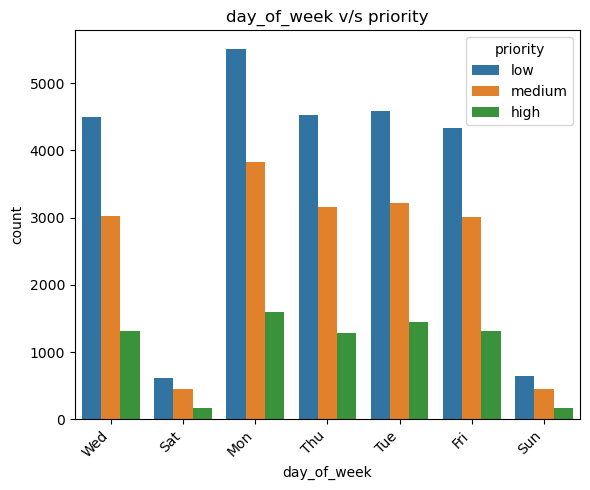

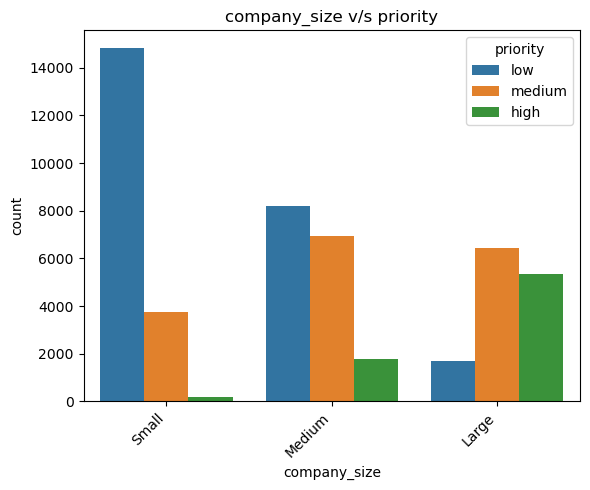

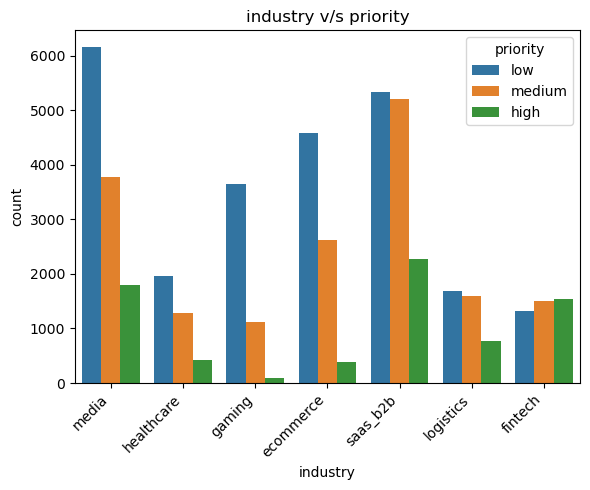

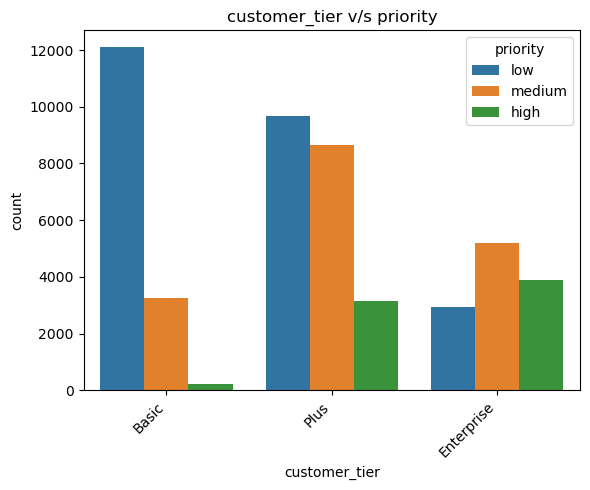

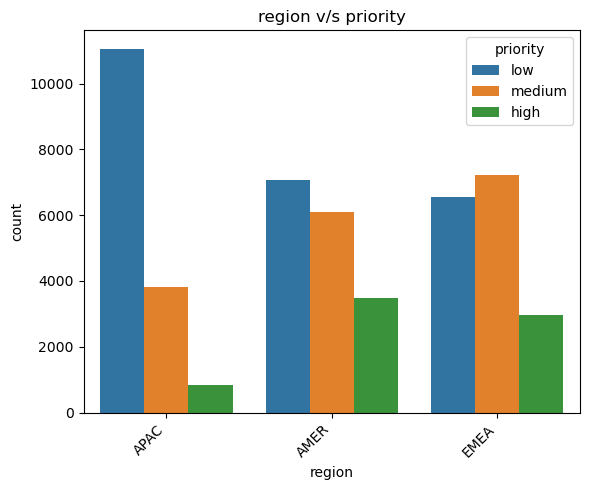

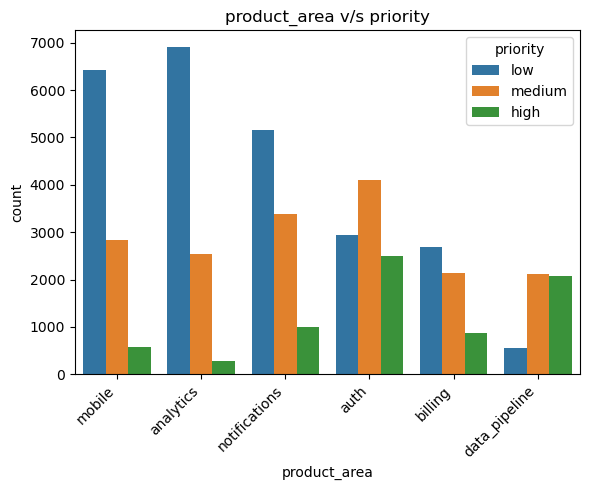

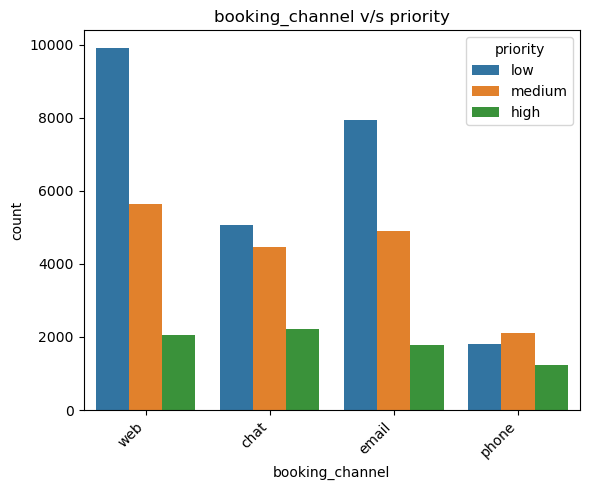

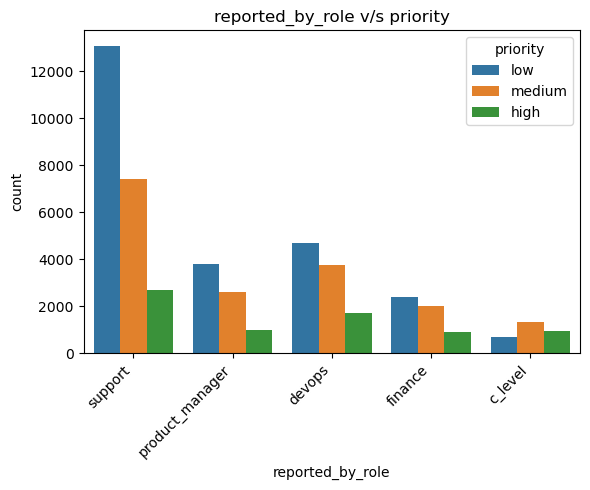

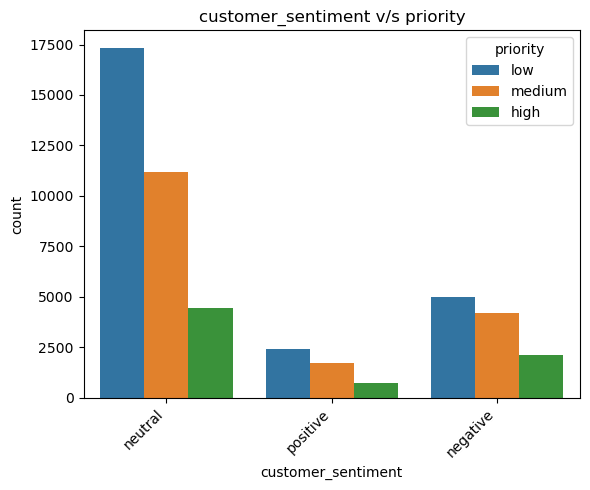

In [11]:
target_col = 'priority'
for col in categorical_col:
    if col!=target_col:
        plt.figure(figsize=(6,5))
        sns.countplot(data=ticket,x=col,hue=target_col)
        plt.xticks(rotation=45,ha='right')
        plt.title(f'{col} v/s {target_col}')
        plt.tight_layout()
        plt.show()

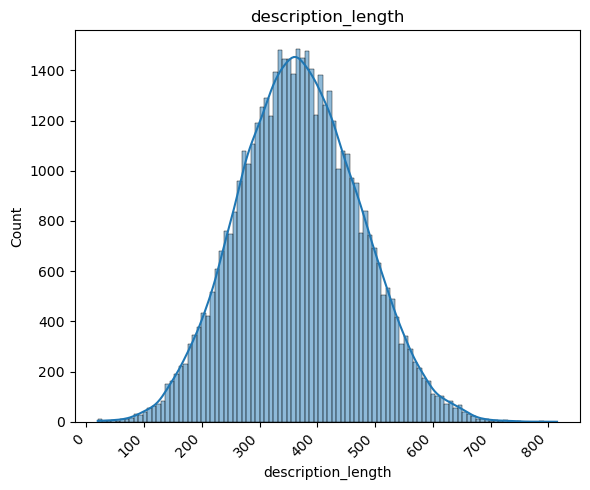

In [12]:
plt.figure(figsize=(6,5))
sns.histplot(data=ticket,x='description_length',kde=True)
plt.xticks(rotation=45,ha='right')
plt.title('description_length')
plt.tight_layout()
plt.show()

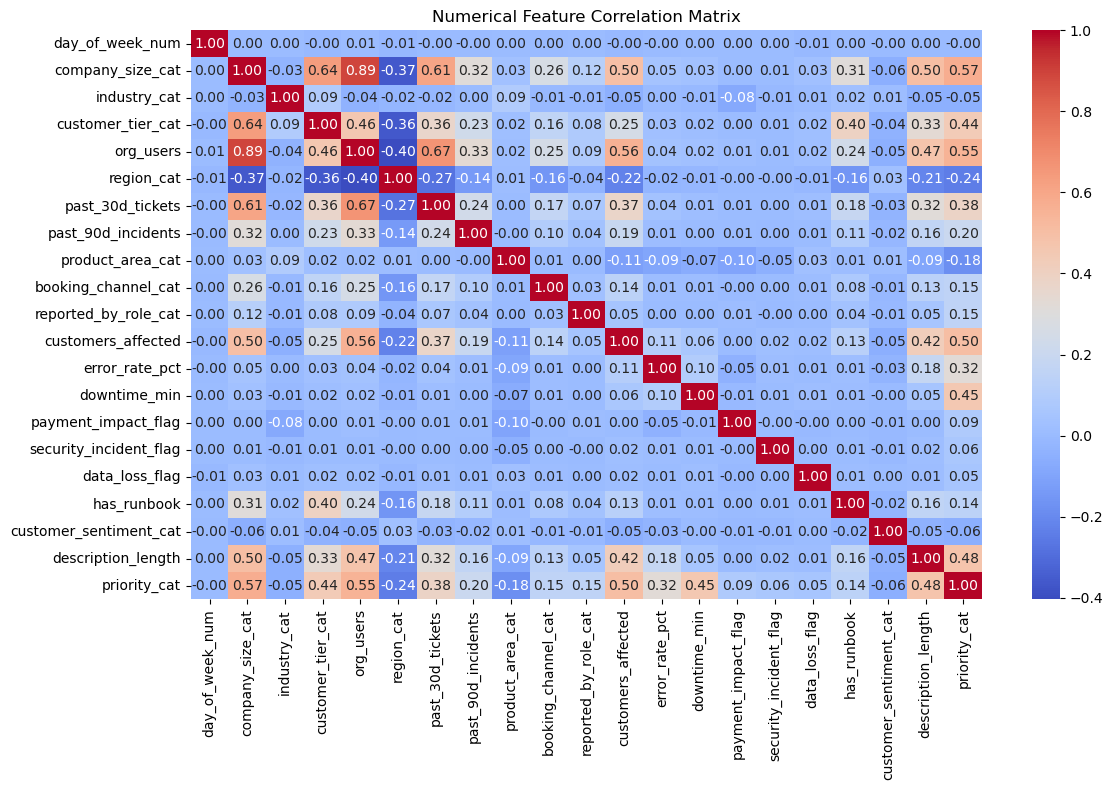

In [14]:
plt.figure(figsize=(12, 8))
# Calculate correlation only on numerical columns
corr_matrix = ticket[numerical_col].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [22]:
print(numerical_col)

['day_of_week_num', 'company_size_cat', 'industry_cat', 'customer_tier_cat', 'org_users', 'region_cat', 'past_30d_tickets', 'past_90d_incidents', 'product_area_cat', 'booking_channel_cat', 'reported_by_role_cat', 'customers_affected', 'error_rate_pct', 'downtime_min', 'payment_impact_flag', 'security_incident_flag', 'data_loss_flag', 'has_runbook', 'customer_sentiment_cat', 'description_length', 'priority_cat']


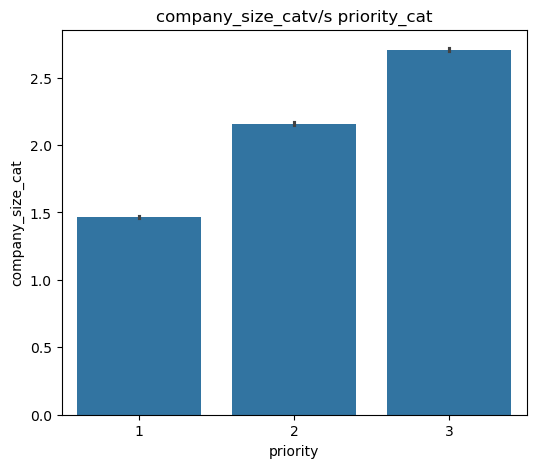

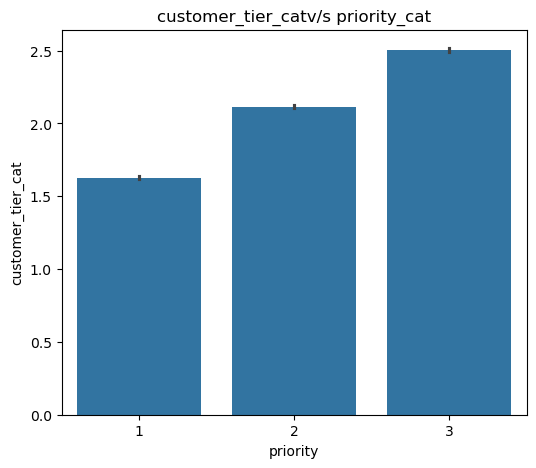

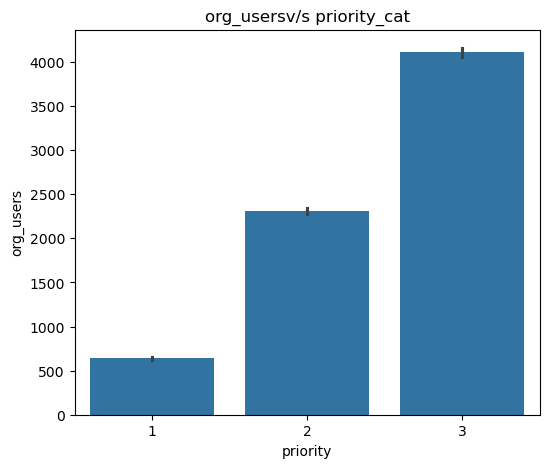

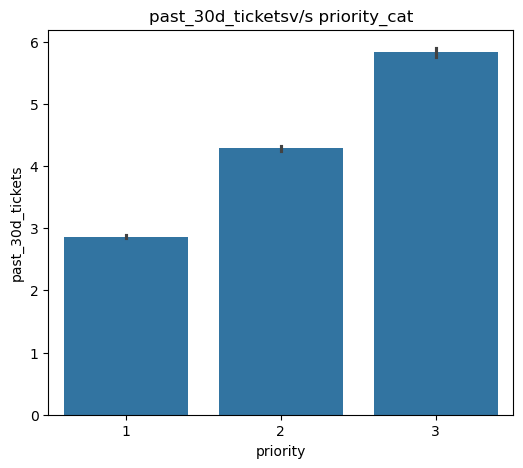

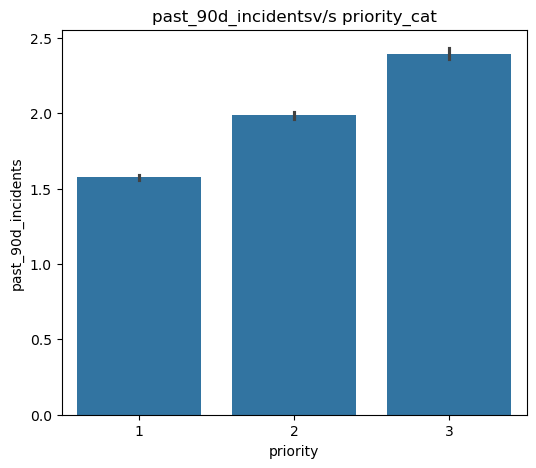

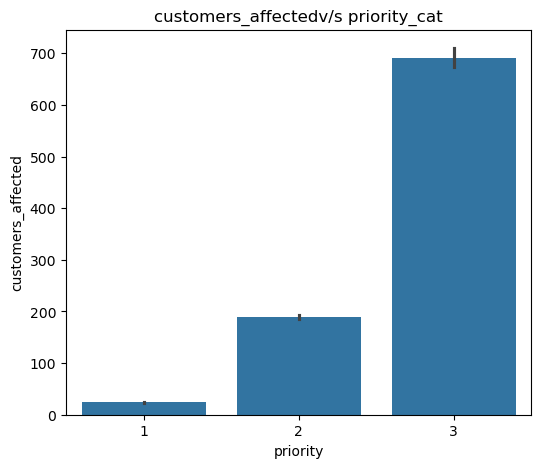

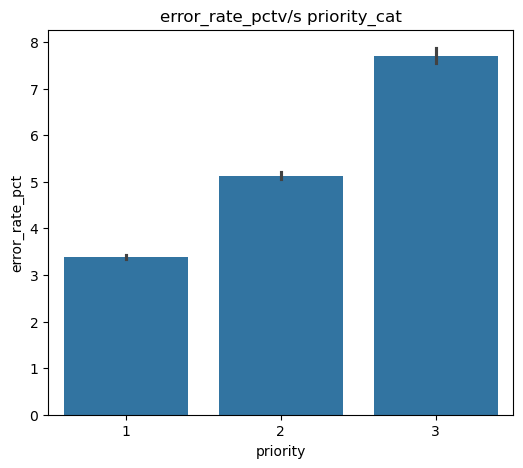

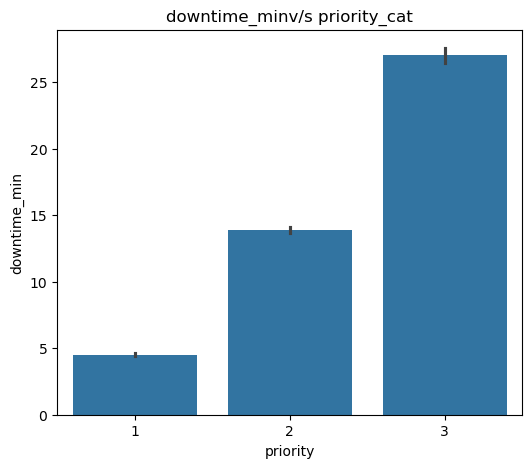

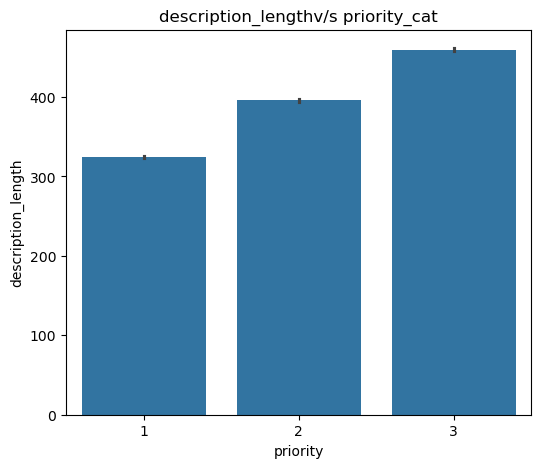

In [45]:
important_col=['company_size_cat','customer_tier_cat','org_users','past_30d_tickets','past_90d_incidents',
     'customers_affected','error_rate_pct','downtime_min','description_length']

new_target='priority_cat'
for name in important_col:
    if name != new_target:
        plt.figure(figsize=(6,5))
        sns.barplot(data=ticket,x=new_target,y=name)
        plt.title(f'{name}v/s priority_cat')
        plt.ylabel(f'{name}')
        plt.xlabel('priority')
        plt.show()

In [42]:
!pip install xgboost lightgbm
from sklearn.metrics import (
    confusion_matrix,f1_score,
    r2_score,mean_absolute_error,mean_squared_error,
    roc_auc_score,RocCurveDisplay
)
from sklearn.model_selection import KFold
from sklearn.svm import SVR                    
from sklearn.tree import DecisionTreeRegressor   
from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor               
from lightgbm import LGBMRegressor              

from sklearn.model_selection import train_test_split,GridSearchCV

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 2.2 MB/s eta 0:00:32
    --------------------------------------- 1.0/69.5 MB 2.0 MB/s eta 0:00:34
    --------------------------------------- 1.6/69.5 MB 1.9 MB/s eta 0:00:37
   - -------------------------------------- 2.4/69.5 MB 2.3 MB/s eta 0:00:30
   - -------------------------------------- 2.9/69.5 MB 2.4 MB/s eta 0:00:28
   -- ------------------------------------- 3.9/69.5 MB 2.8 MB/s eta 0:00:24
   -- ------------------------------------- 4.5/69.5 MB 2.8 MB/s eta 0:00:24
   --- ------------------------------------ 5.2/69.5 MB 2.9 MB/s eta 0:00:23
   --- ------------------------------------ 6.0/69.5 MB 2.9 MB/s eta 0:00:22
   --- ------------------------------------ 6.8/69.5 MB 3.1 MB/s eta 0:00:21
   ---- ----------------------------------- 7.9/69.5 MB 3.2 MB/s eta 0:00:20
   ----- ----

In [50]:

models={
    'SVR':SVR(),
    'decision_tree':DecisionTreeRegressor(random_state=42),
    'random_forest':RandomForestRegressor(random_state=42),
    'XGB':XGBRegressor(random_state=42),
    'LGBM':LGBMRegressor(random_state=42)
}


results=[]
X=ticket[important_col]
y=ticket[new_target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    r2=r2_score(y_test,y_pred)
    absolute_error=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(absolute_error)
    results.append({
        'Model': name,
        'Mean RMSE': rmse,
        'Mean R2': r2,
        'mse':absolute_error      
    })

results_df = pd.DataFrame(results).sort_values(by='Mean R2', ascending=False)
print(results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 39275, number of used features: 9
[LightGBM] [Info] Start training from score 1.643819
           Model  Mean RMSE   Mean R2       mse
4           LGBM   0.400516  0.866182  0.160413
2  random_forest   0.370117  0.863518  0.136986
3            XGB   0.404079  0.862115  0.163280
1  decision_tree   0.369832  0.741672  0.136776
0            SVR   0.557435  0.662683  0.310734


In [50]:

models={
    'SVR':SVR(),
    'decision_tree':DecisionTreeRegressor(random_state=42),
    'random_forest':RandomForestRegressor(random_state=42),
    'XGB':XGBRegressor(random_state=42),
    'LGBM':LGBMRegressor(random_state=42)
}


results=[]
X=ticket[important_col]
y=ticket[new_target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    r2=r2_score(y_test,y_pred)
    absolute_error=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(absolute_error)
    results.append({
        'Model': name,
        'Mean RMSE': rmse,
        'Mean R2': r2,
        'mse':absolute_error      
    })

results_df = pd.DataFrame(results).sort_values(by='Mean R2', ascending=False)
print(results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 39275, number of used features: 9
[LightGBM] [Info] Start training from score 1.643819
           Model  Mean RMSE   Mean R2       mse
4           LGBM   0.400516  0.866182  0.160413
2  random_forest   0.370117  0.863518  0.136986
3            XGB   0.404079  0.862115  0.163280
1  decision_tree   0.369832  0.741672  0.136776
0            SVR   0.557435  0.662683  0.310734


In [50]:

models={
    'SVR':SVR(),
    'decision_tree':DecisionTreeRegressor(random_state=42),
    'random_forest':RandomForestRegressor(random_state=42),
    'XGB':XGBRegressor(random_state=42),
    'LGBM':LGBMRegressor(random_state=42)
}


results=[]
X=ticket[important_col]
y=ticket[new_target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    r2=r2_score(y_test,y_pred)
    absolute_error=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(absolute_error)
    results.append({
        'Model': name,
        'Mean RMSE': rmse,
        'Mean R2': r2,
        'mse':absolute_error      
    })

results_df = pd.DataFrame(results).sort_values(by='Mean R2', ascending=False)
print(results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 39275, number of used features: 9
[LightGBM] [Info] Start training from score 1.643819
           Model  Mean RMSE   Mean R2       mse
4           LGBM   0.400516  0.866182  0.160413
2  random_forest   0.370117  0.863518  0.136986
3            XGB   0.404079  0.862115  0.163280
1  decision_tree   0.369832  0.741672  0.136776
0            SVR   0.557435  0.662683  0.310734


In [52]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}
xgb=XGBRegressor(random_state=42)
kf=KFold(n_splits=5,shuffle=True,random_state=42)

grid_search=GridSearchCV(estimator=xgb,param_grid=param_grid,cv=kf,scoring='r2')
grid_search.fit(X_train,y_train)

print(f"best hyperparameters :{grid_search.best_params_}")
print(f"best training r2_score:{grid_search.best_score_:.3f}")

best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
final_test_r2 = r2_score(y_test, y_pred_xgb)

print(f"Final Optimized Test R2 Score: {final_test_r2:.4f}")

best hyperparameters :{'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 100, 'subsample': 0.8}
best training r2_score:0.876
Final Optimized Test R2 Score: 0.8725


C:\Users\Aditya Kumar\AppData\Local\Temp\ipykernel_27400\339258787.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


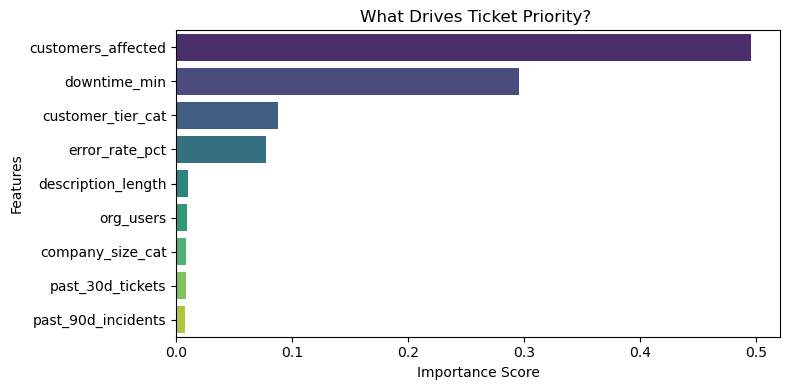

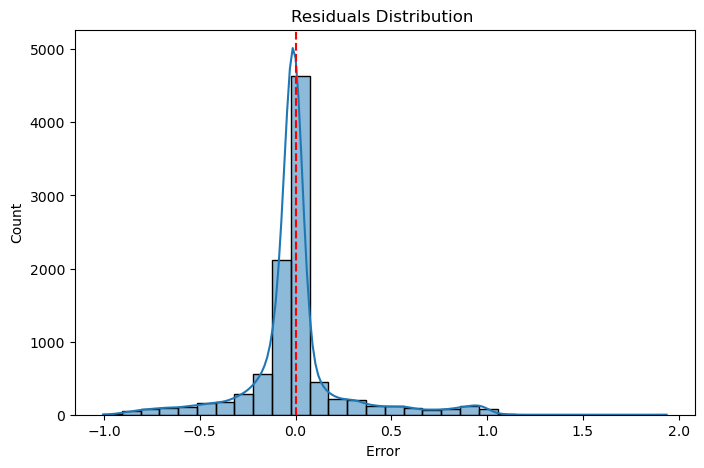

In [55]:
importances = best_xgb.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': important_col,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('What Drives Ticket Priority? ')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


residuals = y_test - y_pred_xgb


plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution ')
plt.xlabel('Error ')
plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

           1       0.94      0.95      0.94      4932
           2       0.87      0.87      0.87      3384
           3       0.91      0.86      0.88      1503

    accuracy                           0.91      9819
   macro avg       0.91      0.89      0.90      9819
weighted avg       0.91      0.91      0.91      9819



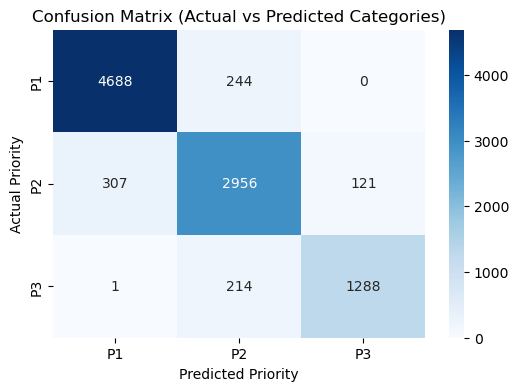

In [56]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_categorical = np.round(y_pred_xgb).astype(int)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_categorical))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_categorical), annot=True, fmt='d', cmap='Blues',
            xticklabels=['P1', 'P2', 'P3'], yticklabels=['P1', 'P2', 'P3'])
plt.title('Confusion Matrix (Actual vs Predicted Categories)')
plt.ylabel('Actual Priority')
plt.xlabel('Predicted Priority')
plt.show()